# Preliminaries (Always run)

In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

# Model Evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
vitpose_path = "/content/drive/Shareddrives/shoplifting-dataset/vitpose_results_70"
yolo_path = "/content/drive/Shareddrives/shoplifting-dataset/pose_estimation_results_70/YOLOv70"
input_path = "/content/drive/Shareddrives/thesis/dataset/split/Shoplifting"
output_path = "/content/drive/Shareddrives/thesis/dataset"

# Loading the Data

In [5]:
df = pd.read_csv(f"{output_path}/features.csv")
df["features"] = df["features"].map(json.loads)
df.head()

,clip,parent,id,features,target
0,Shoplifting001_x264_10,Shoplifting001_x264.mp4,1,"[0.0, 0.0, -0.11117836757117966, -0.1691441296...",1.0
1,Shoplifting001_x264_10,Shoplifting001_x264.mp4,2,"[0.0, 0.0, -0.05169652372232294, -0.0376890645...",1.0
2,Shoplifting001_x264_11,Shoplifting001_x264.mp4,1,"[0.0, 0.0, -0.057816147405604014, -0.073072677...",1.0
3,Shoplifting001_x264_11,Shoplifting001_x264.mp4,5,"[0.0, 0.0, 0.9467400027087208, 0.7246582032086...",1.0
4,Shoplifting001_x264_12,Shoplifting001_x264.mp4,1,"[0.0, 0.0, 0.08609007713653288, 0.050027718282...",1.0


In [6]:
shoplifting_count = df[df["target"] == 1].shape[0]
non_shoplifting_count = df[df["target"] == 0].shape[0]

print(f"Shoplifting count: {shoplifting_count}")
print(f"Non-shoplifting count: {non_shoplifting_count}")

Shoplifting count: 335
Non-shoplifting count: 5120


# Preprocessing the Data

In [7]:
# Separate the input from the output
X = df['features'] # must be a 2D matrix (4 features, 120 samples)
y = df['target'] # 1 for Shoplifting, 0 for Non-shoplifting

In [8]:
# Flatten the 2D matrix into 1D
X_flat = np.vstack(X)
# X_flat = X.reshape(X.shape[0], -1) # (1D array with 480 values)
# print(X_flat)
print(X_flat.shape)

(5455, 6222)


In [9]:
# Split the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=18, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4364, 6222)
X_test shape: (1091, 6222)
y_train shape: (4364,)
y_test shape: (1091,)


In [10]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the Model

## Random Forest

In [11]:
# Parameters for hyperparameter tuning
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initializing the classifier
rf_model = RandomForestClassifier(random_state=18, verbose=2)

# Hyperparameter tuning
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
rf_grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_rf_model = rf_grid_search.best_estimator_
print("Training done!")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tr

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   13.1s


building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   53.8s


building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200
Training done!


In [12]:
# Make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test_scaled)

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
print("Best cross-validation score for Random Forest:", rf_grid_search.best_score_)

Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score for Random Forest: 0.6604347374941024


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.1s


In [13]:
print("Classification Report for Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      1024
         1.0       0.00      0.00      0.00        67

    accuracy                           0.94      1091
   macro avg       0.47      0.50      0.48      1091
weighted avg       0.88      0.94      0.91      1091



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


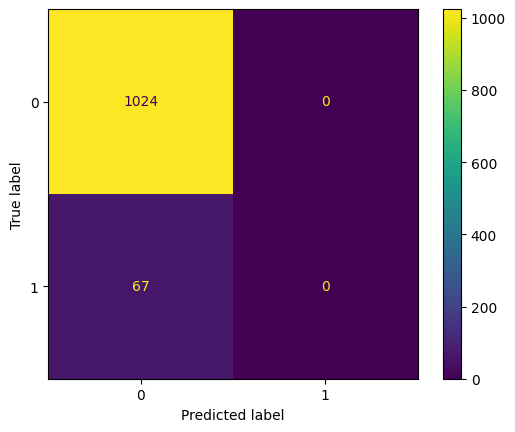

In [14]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

## Logistic Regression

In [15]:
# Parameters for hyperparameter tuning
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [100, 200, 300]
}

# Initializing the classifier
lr_model = LogisticRegression(random_state=18, verbose=1)

# Hyperparameter tuning
lr_grid_search = GridSearchCV(estimator=lr_model, param_grid=lr_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
lr_grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_lr_model = lr_grid_search.best_estimator_
print("Training done!")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
max_iter reached after 26 seconds
Training done!


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [16]:
# Make predictions on the test set
y_pred_lr = best_lr_model.predict(X_test_scaled)

print("Best parameters for Logistic Regression:", lr_grid_search.best_params_)
print("Best cross-validation score for Logistic Regression:", lr_grid_search.best_score_)

Best parameters for Logistic Regression: {'C': 0.1, 'max_iter': 100, 'solver': 'saga'}
Best cross-validation score for Logistic Regression: 0.5595660984831102


In [17]:
print("Classification Report for Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96      1024
         1.0       0.04      0.01      0.02        67

    accuracy                           0.92      1091
   macro avg       0.49      0.50      0.49      1091
weighted avg       0.88      0.92      0.90      1091



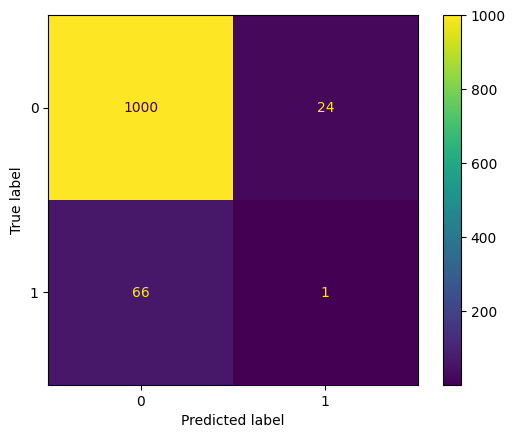

In [18]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

## Support Vector Machine (SVM)

In [19]:
# Parameters for hyperparameter tuning
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initializing the classifier
svm_model = SVC(random_state=18, verbose=True)

# Hyperparameter tuning
svm_grid_search = GridSearchCV(estimator=svm_model, param_grid=svm_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
svm_grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_svm_model = svm_grid_search.best_estimator_
print("Training done!")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LibSVM]Training done!


In [20]:
# Make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test_scaled)

print("Best parameters for SVM:", svm_grid_search.best_params_)
print("Best cross-validation score for SVM:", svm_grid_search.best_score_)

Best parameters for SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score for SVM: 0.614957760883005


In [21]:
print("Classification Report for SVM:\n")
print(classification_report(y_test, y_pred_svm))

Classification Report for SVM:

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      1024
         1.0       0.00      0.00      0.00        67

    accuracy                           0.94      1091
   macro avg       0.47      0.50      0.48      1091
weighted avg       0.88      0.94      0.91      1091



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


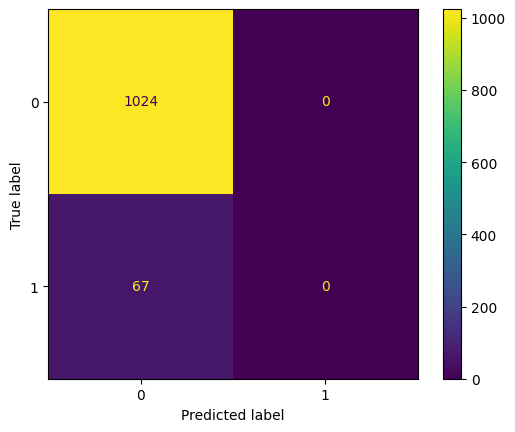

In [22]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

## Decision Tree

In [23]:
# Parameters for hyperparameter tuning
dt_params = {
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initializing the classifier
dt_model = DecisionTreeClassifier(random_state=18)

# Hyperparameter tuning
dt_grid_search = GridSearchCV(estimator=dt_model, param_grid=dt_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
dt_grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_dt_model = dt_grid_search.best_estimator_
print("Training done!")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Training done!


In [24]:
# Make predictions on the test set
y_pred_dt = best_dt_model.predict(X_test_scaled)

print("Best parameters for Decision Tree:", dt_grid_search.best_params_)
print("Best cross-validation score for Decision Tree:", dt_grid_search.best_score_)

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validation score for Decision Tree: 0.5252719127743416


In [25]:
print("Classification Report for Decision Tree:\n")
print(classification_report(y_test, y_pred_dt))

Classification Report for Decision Tree:

              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95      1024
         1.0       0.11      0.09      0.10        67

    accuracy                           0.90      1091
   macro avg       0.53      0.52      0.52      1091
weighted avg       0.89      0.90      0.89      1091



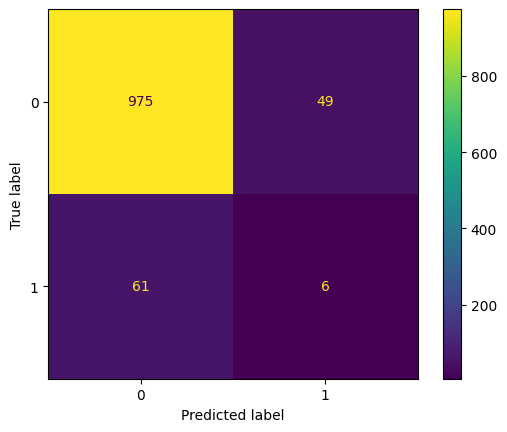

In [26]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

## KNN

In [27]:
# Parameters for hyperparameter tuning
knn_params = {
    'n_neighbors': [3, 5, 10],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Initializing the classifier
knn_model = KNeighborsClassifier()

# Hyperparameter tuning
knn_grid_search = GridSearchCV(estimator=knn_model, param_grid=knn_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
knn_grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_knn_model = knn_grid_search.best_estimator_
print("Training done!")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Training done!


In [28]:
# Make predictions on the test set
y_pred_knn = best_knn_model.predict(X_test_scaled)

print("Best parameters for KNN:", knn_grid_search.best_params_)
print("Best cross-validation score for KNN:", knn_grid_search.best_score_)

Best parameters for KNN: {'algorithm': 'auto', 'n_neighbors': 10, 'weights': 'distance'}
Best cross-validation score for KNN: 0.5680112264435013


In [29]:
print("Classification Report for KNN:\n")
print(classification_report(y_test, y_pred_knn))

Classification Report for KNN:

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      1024
         1.0       0.00      0.00      0.00        67

    accuracy                           0.94      1091
   macro avg       0.47      0.50      0.48      1091
weighted avg       0.88      0.94      0.91      1091



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


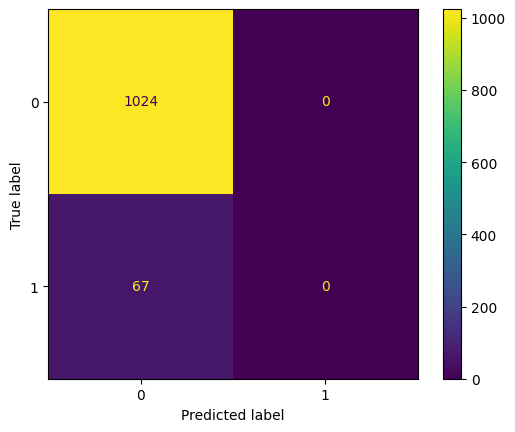

In [30]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

## MLPClassifier

In [31]:
# Parameters for hyperparameter tuning
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'max_iter': [200, 300]
}

# Initializing the classifier
mlp_model = MLPClassifier(random_state=18, verbose=True)

# Hyperparameter tuning
mlp_grid_search = GridSearchCV(estimator=mlp_model, param_grid=mlp_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
mlp_grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_mlp_model = mlp_grid_search.best_estimator_
print("Training done!")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Iteration 1, loss = 0.43787017
Iteration 2, loss = 0.19759969
Iteration 3, loss = 0.15130929
Iteration 4, loss = 0.12248136
Iteration 5, loss = 0.10197495
Iteration 6, loss = 0.09570736
Iteration 7, loss = 0.07897030
Iteration 8, loss = 0.06439591
Iteration 9, loss = 0.06091839
Iteration 10, loss = 0.05825946
Iteration 11, loss = 0.05278936
Iteration 12, loss = 0.04493949
Iteration 13, loss = 0.04361922
Iteration 14, loss = 0.04196496
Iteration 15, loss = 0.03919245
Iteration 16, loss = 0.02996563
Iteration 17, loss = 0.02582226
Iteration 18, loss = 0.02496103
Iteration 19, loss = 0.02652807
Iteration 20, loss = 0.02540619
Iteration 21, loss = 0.02248878
Iteration 22, loss = 0.02276179
Iteration 23, loss = 0.02006824
Iteration 24, loss = 0.02670627
Iteration 25, loss = 0.02252285
Iteration 26, loss = 0.02745968
Iteration 27, loss = 0.03864875
Iteration 28, loss = 0.02604858
Iteration 29, loss = 0.02551779
Iteration 30, loss 

In [32]:
# Make predictions on the test set
y_pred_mlp = best_mlp_model.predict(X_test_scaled)

print("Best parameters for MLP:", mlp_grid_search.best_params_)
print("Best cross-validation score for MLP:", mlp_grid_search.best_score_)

Best parameters for MLP: {'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'max_iter': 200, 'solver': 'adam'}
Best cross-validation score for MLP: 0.5835842977715453


In [33]:
print("Classification Report for MLP:\n")
print(classification_report(y_test, y_pred_mlp))

Classification Report for MLP:

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96      1024
         1.0       0.18      0.07      0.11        67

    accuracy                           0.92      1091
   macro avg       0.56      0.53      0.53      1091
weighted avg       0.89      0.92      0.91      1091



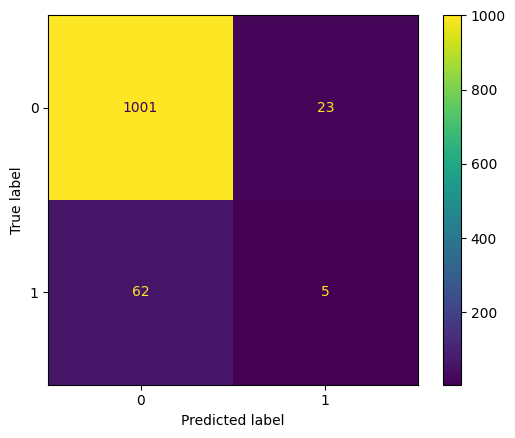

In [34]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()